In [1]:
# تثبيت المكتبات مع إجبار النظام على إصدارات متوافقة مع كرت الشاشة (GPU)
!pip install yfinance fsspec pandas-ta "pandas<2.4.0" "numpy<2.0" --upgrade --no-cache-dir
!pip install cudf-cu12 cuml-cu12 --extra-index-url=https://pypi.nvidia.com

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of pandas-ta to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of pandas-ta to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
Requested yfinance from https://files.pythonhosted.org/packages/f3/23/0e28fa29eba03f33d74c58296f301064930340622be34b008ed02d4486de/yfinance-0.1.91-py2.py3-none-any.whl has invalid metadata: Expected matching RIGHT_PARENTHESIS for LEFT_PARENTHESIS, after version specifier
    appdirs (>=1.4.4cryptography>=3.3.2)
            ~~~~~~~~~~^
Please use pip<24.1 if you need to use this

In [14]:
import yfinance as yf
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# قائمة موسعة تضم 250 شركة أمريكية لضمان كسر حاجز المليون صف
us_tickers = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "TSLA", "META", "BRK-B", "JNJ", "JPM",
    "V", "PG", "UNH", "MA", "DIS", "HD", "CVX", "ABBV", "LLY", "MRK",
    "PEP", "KO", "PFE", "AVGO", "TMO", "COST", "CSCO", "MCD", "ABT", "DHR",
    "CRM", "WMT", "ADBE", "ACN", "VZ", "NEE", "TXN", "LIN", "PM", "RTX",
    "HON", "QCOM", "UNP", "IBM", "INTC", "AMD", "BA", "SPGI", "GS", "MS",
    "NFLX", "INTU", "CAT", "ORCL", "NOW", "NKE", "MDT", "LOW", "BKNG", "BLK",
    "SYK", "TJX", "CB", "GE", "AXP", "C", "T", "PGR", "SCHW", "AMAT",
    "DE", "LRCX", "VRTX", "ZTS", "MCO", "ISRG", "GILD", "REGN", "MDLZ", "ADI",
    "CI", "BSX", "CVS", "BDX", "EL", "FI", "DUK", "SO", "ADP", "CME",
    "SNPS", "MMC", "WM", "CDNS", "ICE", "ITW", "SHW", "KLAC", "TGT", "EOG",
    "AON", "NOC", "CSX", "MCK", "SLB", "FCX", "GD", "MAR", "PH", "KMB",
    "AEP", "VLO", "PSX", "COP", "OXY", "MPC", "PXD", "HES", "HAL", "BKR",
    "CTRA", "FANG", "DVN", "MRO", "TRGP", "WMB", "OKE", "KMI", "EPD", "ET",
    "WES", "PAA", "MMP", "XOM", "SHEL", "TTE", "BP", "EQNR", "PBR", "MMM",
    "ABMD", "ATVI", "ADM", "AAP", "AES", "AFL", "A", "APD", "AKAM", "ALK",
    "ALB", "ARE", "ALGN", "ALLE", "LNT", "ALL", "AMCR", "AEE", "AAL", "AIG",
    "AMT", "AWK", "AMP", "ABC", "AME", "AMGN", "APH", "ANSS", "AOS", "APA",
    "APTV", "ANET", "AJG", "AIZ", "ATO", "ADSK", "AZO", "AVB", "AVY", "BLL",
    "BAC", "BBWI", "BAX", "BBY", "BIO", "TECH", "BIIB", "BK", "BWA", "BXP",
    "BMY", "BR", "BRO", "BF-B", "CHRW", "CZR", "CPT", "CPB", "COF", "CAH",
    "KMX", "CCL", "CARR", "CTLT", "CBOE", "CBRE", "CDW", "CE", "CNC", "CNP",
    "CDAY", "CERN", "CF", "CRL", "CHTR", "CMG", "CHD", "CINF", "CTAS", "CFG",
    "CTXS", "CLX", "CMS", "CTSH", "CL", "CMCSA", "CMA", "CAG", "ED", "STZ",
    "CEG", "COO", "CPRT", "GLW", "CTVA", "CCI", "CMI"
]

start_date = "2007-07-30"
end_date = "2026-08-05"

print("جاري سحب بيانات الاقتصاد الكلي الخام...")
# الاعتماد على خام برنت كما طلبت
macro_data = yf.download(["BZ=F", "GC=F"], start=start_date, end=end_date, progress=False)['Close']
macro_data.columns = ['Oil_Close', 'Gold_Close']
macro_data.ffill(inplace=True)

all_raw_data = []

for ticker in us_tickers:
    print(f"جاري سحب بيانات: {ticker} ...")
    try:
        df = yf.download(ticker, start=start_date, end=end_date, progress=False)

        if df.empty or len(df) < 50:
            continue

        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        df['Ticker'] = ticker

        # دمج المتغيرات الكلية مع بيانات السهم الخام
        df = df.join(macro_data, how='left')
        df.ffill(inplace=True)

        all_raw_data.append(df)

    except Exception as e:
        print(f"تخطي {ticker}")

print("\nجاري تجميع وحفظ البيانات الخام...")
if len(all_raw_data) > 0:
    raw_df = pd.concat(all_raw_data)
    raw_output = "US_Raw_Data_Million.csv"
    raw_df.to_csv(raw_output)
    print(f"تم حفظ البيانات الخام بنجاح في: {raw_output}")
    print(f"إجمالي عدد الصفوف الخام: {len(raw_df):,}")

جاري سحب بيانات الاقتصاد الكلي الخام...
جاري سحب بيانات: AAPL ...
جاري سحب بيانات: MSFT ...
جاري سحب بيانات: GOOGL ...
جاري سحب بيانات: AMZN ...
جاري سحب بيانات: NVDA ...
جاري سحب بيانات: TSLA ...
جاري سحب بيانات: META ...
جاري سحب بيانات: BRK-B ...
جاري سحب بيانات: JNJ ...
جاري سحب بيانات: JPM ...
جاري سحب بيانات: V ...
جاري سحب بيانات: PG ...
جاري سحب بيانات: UNH ...
جاري سحب بيانات: MA ...
جاري سحب بيانات: DIS ...
جاري سحب بيانات: HD ...
جاري سحب بيانات: CVX ...
جاري سحب بيانات: ABBV ...
جاري سحب بيانات: LLY ...
جاري سحب بيانات: MRK ...
جاري سحب بيانات: PEP ...
جاري سحب بيانات: KO ...
جاري سحب بيانات: PFE ...
جاري سحب بيانات: AVGO ...
جاري سحب بيانات: TMO ...
جاري سحب بيانات: COST ...
جاري سحب بيانات: CSCO ...
جاري سحب بيانات: MCD ...
جاري سحب بيانات: ABT ...
جاري سحب بيانات: DHR ...
جاري سحب بيانات: CRM ...
جاري سحب بيانات: WMT ...
جاري سحب بيانات: ADBE ...
جاري سحب بيانات: ACN ...
جاري سحب بيانات: VZ ...
جاري سحب بيانات: NEE ...
جاري سحب بيانات: TXN ...
جاري سحب بيانات: LIN ...
جا

ERROR:yfinance:$FI: possibly delisted; no timezone found
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['FI']: possibly delisted; no timezone found


جاري سحب بيانات: FI ...
جاري سحب بيانات: DUK ...
جاري سحب بيانات: SO ...
جاري سحب بيانات: ADP ...
جاري سحب بيانات: CME ...
جاري سحب بيانات: SNPS ...
جاري سحب بيانات: MMC ...


ERROR:yfinance:$MMC: possibly delisted; no timezone found
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['MMC']: possibly delisted; no timezone found


جاري سحب بيانات: WM ...
جاري سحب بيانات: CDNS ...
جاري سحب بيانات: ICE ...
جاري سحب بيانات: ITW ...
جاري سحب بيانات: SHW ...
جاري سحب بيانات: KLAC ...
جاري سحب بيانات: TGT ...
جاري سحب بيانات: EOG ...
جاري سحب بيانات: AON ...
جاري سحب بيانات: NOC ...
جاري سحب بيانات: CSX ...
جاري سحب بيانات: MCK ...
جاري سحب بيانات: SLB ...
جاري سحب بيانات: FCX ...
جاري سحب بيانات: GD ...
جاري سحب بيانات: MAR ...
جاري سحب بيانات: PH ...
جاري سحب بيانات: KMB ...
جاري سحب بيانات: AEP ...
جاري سحب بيانات: VLO ...
جاري سحب بيانات: PSX ...
جاري سحب بيانات: COP ...
جاري سحب بيانات: OXY ...
جاري سحب بيانات: MPC ...
جاري سحب بيانات: PXD ...


...

جاري سحب بيانات: CF ...
جاري سحب بيانات: CRL ...
جاري سحب بيانات: CHTR ...
جاري سحب بيانات: CMG ...
جاري سحب بيانات: CHD ...
جاري سحب بيانات: CINF ...
جاري سحب بيانات: CTAS ...
جاري سحب بيانات: CFG ...
جاري سحب بيانات: CTXS ...


ERROR:yfinance:$CTXS: possibly delisted; no timezone found
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['CTXS']: possibly delisted; no timezone found


جاري سحب بيانات: CLX ...
جاري سحب بيانات: CMS ...
جاري سحب بيانات: CTSH ...
جاري سحب بيانات: CL ...
جاري سحب بيانات: CMCSA ...


ERROR:yfinance:$CMA: possibly delisted; no timezone found
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['CMA']: possibly delisted; no timezone found


جاري سحب بيانات: CMA ...
جاري سحب بيانات: CAG ...
جاري سحب بيانات: ED ...
جاري سحب بيانات: STZ ...
جاري سحب بيانات: CEG ...
جاري سحب بيانات: COO ...
جاري سحب بيانات: CPRT ...
جاري سحب بيانات: GLW ...
جاري سحب بيانات: CTVA ...
جاري سحب بيانات: CCI ...
جاري سحب بيانات: CMI ...

جاري تجميع وحفظ البيانات الخام...
تم حفظ البيانات الخام بنجاح في: US_Raw_Data_Million.csv
إجمالي عدد الصفوف الخام: 1,012,317


In [2]:
import pandas as pd
import pandas_ta as ta
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("/content/US_Raw_Data_Million (2).csv")

# تحديد عمود التاريخ وتنسيقه كمؤشر زمني (Index)
date_col = 'Date' if 'Date' in df.columns else 'Unnamed: 0'
df[date_col] = pd.to_datetime(df[date_col])
df.set_index(date_col, inplace=True)

# تطبيق الترتيب الزمني الصارم
df = df.sort_values(by=['Ticker', date_col])

engineered_data = []
grouped_data = df.groupby('Ticker')

print("جاري بناء المؤشرات الفنية (بدون Lags) لكل سهم...")
for ticker, group_df in grouped_data:

    # 1. مؤشرات الزخم والسيولة
    try:
        group_df.ta.vwap(append=True)
        group_df.ta.mfi(length=14, append=True)
        group_df.ta.rsi(length=14, append=True)
    except:
        pass

    # 2. مؤشرات الاتجاه والتذبذب
    group_df['SMA_7'] = group_df['Close'].rolling(window=7).mean()
    group_df['Volatility_7'] = group_df['Close'].rolling(window=7).std()

    # 3. المتغير المستهدف (عائد 5 أيام)
    group_df['Future_Close_5d'] = group_df['Close'].shift(-5)
    group_df['Target_Return'] = np.log(group_df['Future_Close_5d'] / group_df['Close'])

    # تنظيف الصفوف الفارغة
    group_df.dropna(inplace=True)

    engineered_data.append(group_df)

print("\nجاري تجميع البيانات النهائية المعالجة...")
final_df = pd.concat(engineered_data)

# حفظ الملف باسم مميز لتعرف أنه النسخة الخالية من الـ Lags
final_output = "US_Engineered_Features_No_Lag_Stock.csv"
final_df.to_csv(final_output)

print(f"تمت العملية بنجاح! تم حفظ الملف باسم: {final_output}")
print(f"إجمالي عدد الصفوف الجاهزة للتدريب: {len(final_df):,}")
print(f"إجمالي عدد الأعمدة (الميزات): {len(final_df.columns)}")

جاري بناء المؤشرات الفنية (بدون Lags) لكل سهم...

جاري تجميع البيانات النهائية المعالجة...
تمت العملية بنجاح! تم حفظ الملف باسم: US_Engineered_Features_No_Lag_Stock.csv
إجمالي عدد الصفوف الجاهزة للتدريب: 1,006,776
إجمالي عدد الأعمدة (الميزات): 15


In [3]:
import cudf

print("جاري تحميل البيانات الخام إلى ذاكرة الـ GPU...")
# قراءة الملف الخام (تأكد من اسم الملف الذي حفظته في الخطوة السابقة)
df_gpu = cudf.read_csv("/content/US_Engineered_Features_No_Lag_Stock.csv")

# 1. فحص الشكل العام للبيانات
print("\n--- 1. نظرة عامة على البيانات ---")
print(f"إجمالي عدد الصفوف: {len(df_gpu):,}")
print(f"إجمالي عدد الأعمدة: {len(df_gpu.columns)}")

# 2. فحص القيم المفقودة (Null)
print("\n--- 2. فحص القيم المفقودة ---")
# يجب أن تكون أسعار النفط والذهب 0 مفقود لأننا سحبناها بآلية التطابق
null_counts = df_gpu.isnull().sum()
print(null_counts)

# 3. فحص التواريخ وتطابقها
print("\n--- 3. فحص تطابق التواريخ ---")
# ياهو فاينانس عادة يحفظ التاريخ في عمود يسمى 'Date' أو 'Unnamed: 0'
date_col = 'Date' if 'Date' in df_gpu.columns else 'Unnamed: 0'

if date_col in df_gpu.columns:
    # تحويل العمود إلى صيغة تاريخ لمعالجته
    df_gpu[date_col] = cudf.to_datetime(df_gpu[date_col])

    min_date = df_gpu[date_col].min()
    max_date = df_gpu[date_col].max()

    print(f"أقدم تاريخ تداول في الملف: {min_date}")
    print(f"أحدث تاريخ تداول في الملف: {max_date}")

    # التحقق من عدد أيام التداول لكل شركة
    date_counts = df_gpu.groupby('Ticker')[date_col].count().sort_values()

    print("\n--- الشركات الأقل من حيث عدد أيام التداول ---")
    print(date_counts.head(5))

    print("\n--- الشركات الأكثر من حيث عدد أيام التداول ---")
    print(date_counts.tail(5))
else:
    print("لم يتم العثور على عمود التاريخ، يرجى التحقق من أسماء الأعمدة:")
    print(df_gpu.columns)

جاري تحميل البيانات الخام إلى ذاكرة الـ GPU...

--- 1. نظرة عامة على البيانات ---
إجمالي عدد الصفوف: 1,006,776
إجمالي عدد الأعمدة: 16

--- 2. فحص القيم المفقودة ---
Date               0
Close              0
High               0
Low                0
Open               0
Volume             0
Ticker             0
Oil_Close          0
Gold_Close         0
VWAP_D             0
MFI_14             0
RSI_14             0
SMA_7              0
Volatility_7       0
Future_Close_5d    0
Target_Return      0
dtype: int64

--- 3. فحص تطابق التواريخ ---
أقدم تاريخ تداول في الملف: 2007-08-17T00:00:00.000000000
أحدث تاريخ تداول في الملف: 2026-07-28T00:00:00.000000000

--- الشركات الأقل من حيث عدد أيام التداول ---
Ticker
CEG     1120
CARR    1583
CTVA    1789
AMCR    2199
CFG     2963
Name: Date, dtype: int64

--- الشركات الأكثر من حيث عدد أيام التداول ---
Ticker
DVN     4765
CNP     4765
BBWI    4765
TECH    4765
ALK     4765
Name: Date, dtype: int64


### Check Duplicate and data type

In [4]:
print(df_gpu.duplicated().sum())

df_gpu.dtypes

0


,0
Date,datetime64[ns]
Close,float64
High,float64
Low,float64
Open,float64
Volume,int64
Ticker,object
Oil_Close,float64
Gold_Close,float64
VWAP_D,float64


In [5]:
df_gpu.describe()

,Date,Close,High,Low,Open,Volume,Oil_Close,Gold_Close,VWAP_D,MFI_14,RSI_14,SMA_7,Volatility_7,Future_Close_5d,Target_Return
count,1006776,1.006776e+06,1.006776e+06,1.006776e+06,1.006776e+06,1.006776e+06,1.006776e+06,1.006776e+06,1.006776e+06,1.006776e+06,1.006776e+06,1.006776e+06,1.006776e+06,1.006776e+06,1.006776e+06
mean,2017-04-18 07:42:36.532932864,9.084362e+01,9.183681e+01,8.980763e+01,9.083348e+01,1.302482e+07,7.812793e+01,1.671094e+03,9.082935e+01,5.255381e+01,5.276423e+01,9.071835e+01,1.570389e+00,9.105309e+01,2.141112e-03
min,2007-08-17 00:00:00,1.350683e-01,1.460570e-01,1.316344e-01,1.373577e-01,2.000000e+01,1.933000e+01,6.567000e+02,1.390364e-01,0.000000e+00,0.000000e+00,1.507991e-01,0.000000e+00,1.350683e-01,-2.144361e+00
25%,2012-09-05 00:00:00.000000000,2.468226e+01,2.498050e+01,2.436881e+01,2.468054e+01,1.536800e+06,6.128000e+01,1.225300e+03,2.468210e+01,4.143105e+01,4.442123e+01,2.465999e+01,3.223838e-01,2.472946e+01,-1.816143e-02
50%,2017-05-16 00:00:00.000000000,4.905891e+01,4.956603e+01,4.851529e+01,4.904962e+01,3.458900e+06,7.555000e+01,1.408400e+03,4.903979e+01,5.276618e+01,5.298443e+01,4.898773e+01,6.907793e-01,4.916777e+01,3.576581e-03
75%,2021-12-27 00:00:00.000000000,1.030706e+02,1.041161e+02,1.019500e+02,1.030503e+02,8.469600e+06,9.792000e+01,1.829300e+03,1.030493e+02,6.380955e+01,6.129279e+01,1.029339e+02,1.573188e+00,1.033410e+02,2.426445e-02
max,2026-07-28 00:00:00,4.354540e+03,4.388110e+03,4.316680e+03,4.334810e+03,3.692928e+09,1.460800e+02,5.318400e+03,4.335510e+03,1.000000e+02,9.984914e+01,4.274403e+03,2.213407e+02,4.354540e+03,1.374024e+00
std,<NA>,1.509661e+02,1.525767e+02,1.492633e+02,1.509339e+02,5.654057e+07,2.368074e+01,7.981869e+02,1.509313e+02,1.582573e+01,1.197613e+01,1.507405e+02,3.213382e+00,1.512800e+02,4.670642e-02


--- [1] الإحصاءات الوصفية الدقيقة (تعمل على GPU) ---
                                Date         Close          High  \
count                        1006776  1.006776e+06  1.006776e+06   
mean   2017-04-18 07:42:36.532932864  9.084362e+01  9.183681e+01   
min              2007-08-17 00:00:00  1.350683e-01  1.460570e-01   
25%    2012-09-05 00:00:00.000000000  2.468226e+01  2.498050e+01   
50%    2017-05-16 00:00:00.000000000  4.905891e+01  4.956603e+01   
75%    2021-12-27 00:00:00.000000000  1.030706e+02  1.041161e+02   
max              2026-07-28 00:00:00  4.354540e+03  4.388110e+03   
std                             <NA>  1.509661e+02  1.525767e+02   

                Low          Open        Volume     Oil_Close    Gold_Close  \
count  1.006776e+06  1.006776e+06  1.006776e+06  1.006776e+06  1.006776e+06   
mean   8.980763e+01  9.083348e+01  1.302482e+07  7.812793e+01  1.671094e+03   
min    1.316344e-01  1.373577e-01  2.000000e+01  1.933000e+01  6.567000e+02   
25%    2.436881e+0

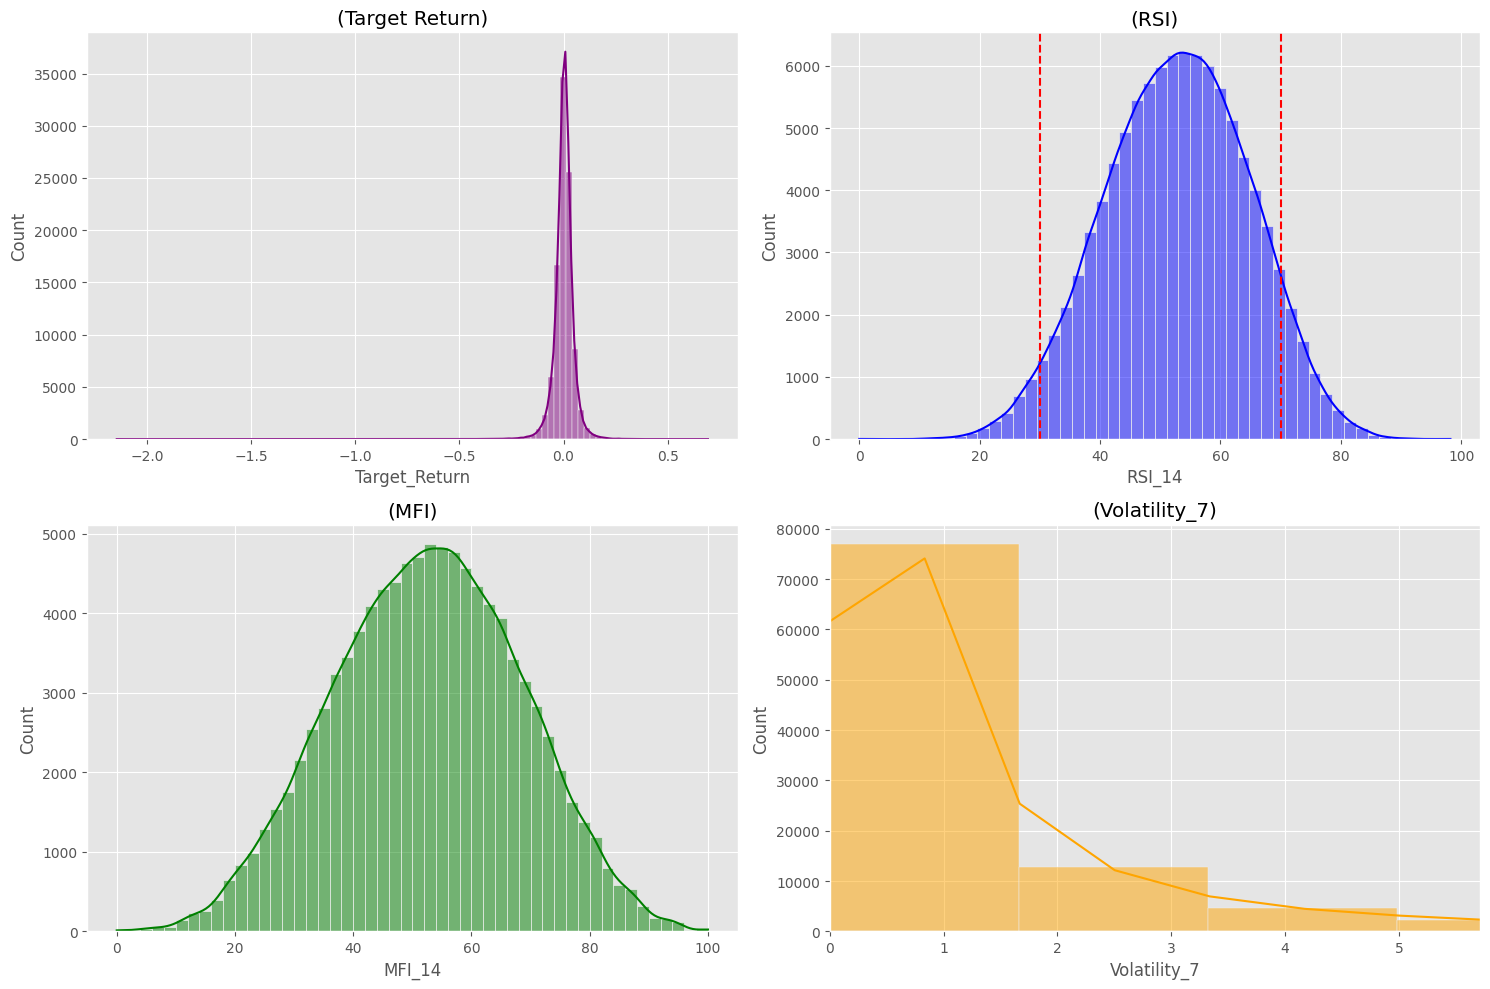

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# إعدادات الشكل العام للرسوم البيانية
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (15, 10)

print("--- [1] الإحصاءات الوصفية الدقيقة (تعمل على GPU) ---")
# تحديد الأعمدة الرقمية فقط لضمان عدم حدوث أخطاء
numeric_cols = [col for col in df_gpu.columns if col not in ['Ticker']]
desc_stats = df_gpu[numeric_cols].describe()
print(desc_stats)

print("جاري أخذ عينة عشوائية (10%) ونقلها للـ CPU لتسريع الرسم بأمان...")
# أخذ عينة عشوائية لضمان عدم تعليق النظام
sample_df = df_gpu.sample(frac=0.1, random_state=42).to_pandas()


print("\n--- [3] رسم التوزيعات للميزات الأساسية (Distributions) ---")
# إنشاء شبكة رسومات (Subplots) لعرض عدة مؤشرات معاً
fig, axes = plt.subplots(2, 2)

# 1. توزيع الهدف (Target Return)
sns.histplot(sample_df['Target_Return'], bins=100, kde=True, ax=axes[0, 0], color='purple')
axes[0, 0].set_title('(Target Return)')

# 2. توزيع مؤشر القوة النسبية (RSI)
sns.histplot(sample_df['RSI_14'], bins=50, kde=True, ax=axes[0, 1], color='blue')
axes[0, 1].set_title('(RSI)')
axes[0, 1].axvline(30, color='r', linestyle='--') # خط ذروة البيع
axes[0, 1].axvline(70, color='r', linestyle='--') # خط ذروة الشراء

# 3. توزيع مؤشر السيولة (MFI)
sns.histplot(sample_df['MFI_14'], bins=50, kde=True, ax=axes[1, 0], color='green')
axes[1, 0].set_title('(MFI)')

# 4. توزيع التذبذب (Volatility)
sns.histplot(sample_df['Volatility_7'], bins=100, kde=True, ax=axes[1, 1], color='orange')
axes[1, 1].set_title('(Volatility_7)')
# التركيز على القيم الطبيعية وتجاهل القيم الشاذة جداً لتوضيح الرسم
axes[1, 1].set_xlim(0, sample_df['Volatility_7'].quantile(0.95))

plt.tight_layout()
plt.show()

جاري رسم الخريطة الحرارية...


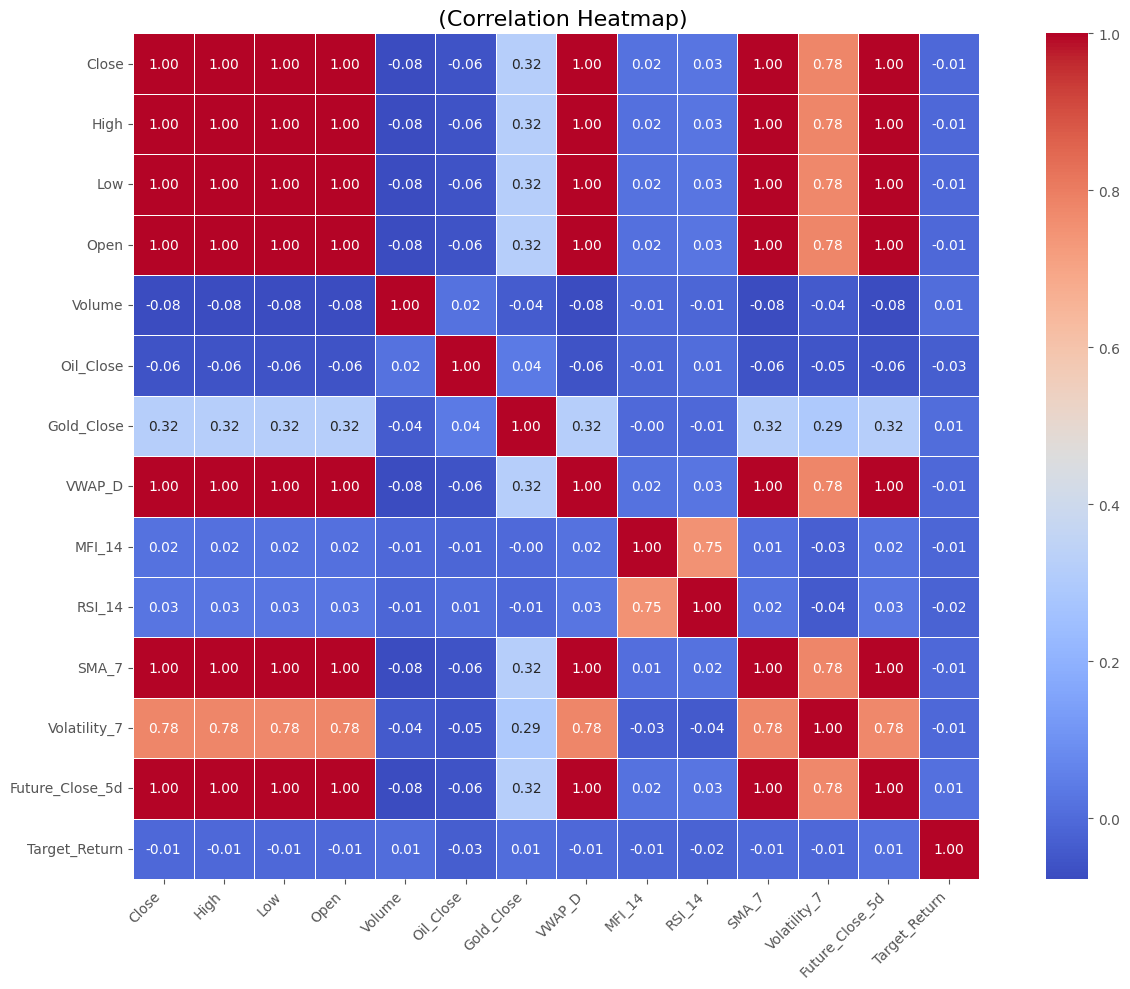


--- علاقة الميزات بالعائد المستهدف (Target_Return) ---
Future_Close_5d    0.013337
Gold_Close         0.006057
Volume             0.005033
Volatility_7      -0.007978
SMA_7             -0.008796
Open              -0.009058
Low               -0.009099
High              -0.009176
VWAP_D            -0.009194
Close             -0.009305
MFI_14            -0.011726
RSI_14            -0.021007
Oil_Close         -0.031813
Name: Target_Return, dtype: float64


In [7]:
# الحل الجذري: تحديد الأعمدة الرقمية فقط (يتجاهل التواريخ والنصوص تلقائياً)
numeric_df_gpu =df_gpu.select_dtypes(include=['number'])

# حساب الارتباط (هذه العملية ستتم في أجزاء من الثانية بفضل cuDF)
corr_matrix_gpu = numeric_df_gpu.corr()

# نقل مصفوفة النتيجة (وهي جدول صغير جداً) إلى Pandas لكي يتمكن Seaborn من رسمها
corr_matrix_cpu = corr_matrix_gpu.to_pandas()

print("جاري رسم الخريطة الحرارية...")
plt.figure(figsize=(14, 10))
# رسم الخريطة مع إظهار القيم بمرتبتين عشريتين (fmt='.2f')
sns.heatmap(corr_matrix_cpu, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, square=True)

plt.title('  (Correlation Heatmap)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# طباعة قائمة مرتبة توضح علاقة كل ميزة بالمتغير المستهدف
print("\n--- علاقة الميزات بالعائد المستهدف (Target_Return) ---")
target_correlations = corr_matrix_cpu['Target_Return'].sort_values(ascending=False)
print(target_correlations.drop('Target_Return'))

بيانات التدريب: 805,420 صف
بيانات الاختبار: 201,356 صف
جذر متوسط مربع الخطأ (RMSE): 0.04196
 متوسط مربع الخطأ (MSE): 0.00176
متوسط الخطأ المطلق (MAE): 0.02848

--- [4] رسم أهمية الميزات (Feature Importance) ---


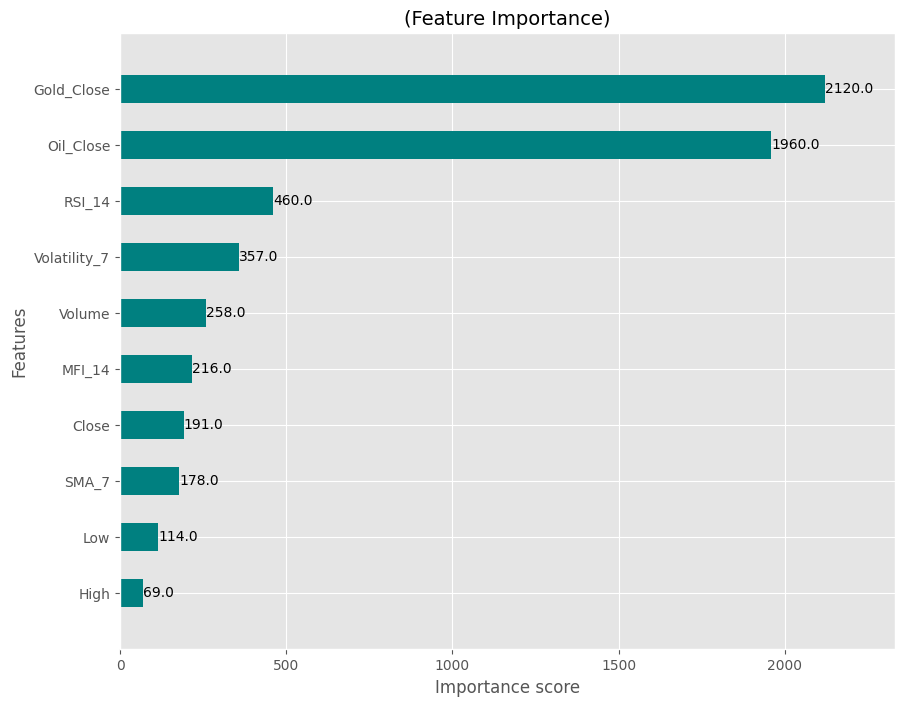

In [8]:
import xgboost as xgb
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# استبعاد المتغير المستهدف، وعمود المستقبل، والنصوص لضمان عدم حدوث تسريب
features = [col for col in df_gpu.columns if col not in ['Date','Target_Return', 'Future_Close_5d', 'Ticker']]

X = df_gpu[features]
y = df_gpu['Target_Return']

# اقتطاع 80% للتدريب و 20% للاختبار بشكل متسلسل زمنياً
split_idx = int(len(df_gpu) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"بيانات التدريب: {len(X_train):,} صف")
print(f"بيانات الاختبار: {len(X_test):,} صف")

# إعداد هايبر-بارامترز متوازنة لتجنب التعلم الزائد (Overfitting)
model = xgb.XGBRegressor(
    n_estimators=200,        # عدد الأشجار
    max_depth=5,             # عمق كل شجرة (متوسط لتجنب حفظ البيانات)
    learning_rate=0.05,      # سرعة التعلم
    tree_method='hist',      # الخوارزمية الأسرع والأكثر كفاءة للبيانات الضخمة
    device='cuda',           # التوجيه الحصري لمعمارية CUDA
    random_state=42
)

# بدء التدريب (نحولها لـ Pandas مؤقتاً لتوافق واجهة sklearn التامة)
model.fit(X_train.to_pandas(), y_train.to_pandas())

# التنبؤ ببيانات الاختبار (الـ 20% التي لم يرها النموذج من قبل)
y_pred = model.predict(X_test.to_pandas())
y_test_cpu = y_test.to_pandas()

# حساب مقاييس الخطأ
rmse = np.sqrt(mean_squared_error(y_test_cpu, y_pred))
mse = mean_squared_error(y_test_cpu, y_pred)
mae = mean_absolute_error(y_test_cpu, y_pred)

print(f"جذر متوسط مربع الخطأ (RMSE): {rmse:.5f}")
print(f" متوسط مربع الخطأ (MSE): {mse:.5f}")
print(f"متوسط الخطأ المطلق (MAE): {mae:.5f}")

print("\n--- [4] رسم أهمية الميزات (Feature Importance) ---")
# الشكل الجمالي للرسم البياني
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 8)

# استخراج ورسم الميزات التي أثرت بشكل أكبر على قرارات النموذج
xgb.plot_importance(model, max_num_features=10, height=0.5, importance_type='weight', color='teal')
plt.title('(Feature Importance)', fontsize=14)
plt.show()

In [9]:
print("--- [1] تجميع التوقعات والنتائج الفعلية ---")
# 1. أخذ نسخة من بيانات الاختبار (أحدث 20% من الأيام)
results_df = X_test.to_pandas().copy()

# 2. استرجاع رمز الشركة وسعر الإغلاق من البيانات الأصلية (لمطابقة التواريخ)
results_df['Ticker'] = df_gpu['Ticker'].to_pandas().loc[results_df.index]
results_df['Current_Close'] = df_gpu['Close'].to_pandas().loc[results_df.index]

# 3. دمج العائد اللوغاريتمي الفعلي والمتوقع في نفس الجدول
results_df['Actual_Log_Return'] = y_test.to_pandas()
results_df['Predicted_Log_Return'] = y_pred

print("--- [2] تحويل العوائد إلى أسعار فعلية (بالدولار) ---")
# المعادلة الرياضية العكسية: السعر المستقبلي = السعر الحالي * exp(العائد اللوغاريتمي)
results_df['Predicted_Future_Price'] = results_df['Current_Close'] * np.exp(results_df['Predicted_Log_Return'])
results_df['Actual_Future_Price'] = results_df['Current_Close'] * np.exp(results_df['Actual_Log_Return'])

# حساب هامش الخطأ بالدولار لكل سهم
results_df['Error_in_Dollars'] = abs(results_df['Actual_Future_Price'] - results_df['Predicted_Future_Price'])

print("\n--- [3] عرض عينة من التوقعات مقابل الواقع ---")
# اختيار الأعمدة الأهم لتكون القراءة مريحة للعين
columns_to_show = [
    'Ticker',
    'Current_Close',
    'Predicted_Future_Price',
    'Actual_Future_Price',
    'Error_in_Dollars'
]

# ترتيب البيانات لعرض أحدث التواريخ في قاعدة بياناتك (أواخر يوليو وبداية أغسطس)
final_display = results_df[columns_to_show].sort_index(ascending=False)

# طباعة أول 20 سطر (أحدث الأيام) لترى المقارنة
print(final_display.head(20).round(2))

print("\n--- ملخص دقة النموذج بالدولار ---")
print(f"متوسط الخطأ بالدولار للسهم الواحد: ${results_df['Error_in_Dollars'].mean():.2f}")

--- [1] تجميع التوقعات والنتائج الفعلية ---
--- [2] تحويل العوائد إلى أسعار فعلية (بالدولار) ---

--- [3] عرض عينة من التوقعات مقابل الواقع ---
        Ticker  Current_Close  Predicted_Future_Price  Actual_Future_Price  \
1006775    ZTS          77.51                   77.59                76.04   
1006774    ZTS          76.92                   76.98                77.10   
1006773    ZTS          75.35                   75.49                77.29   
1006772    ZTS          74.57                   74.96                76.03   
1006771    ZTS          74.19                   74.28                77.93   
1006770    ZTS          75.35                   75.39                77.51   
1006769    ZTS          76.20                   76.31                76.92   
1006768    ZTS          76.03                   76.23                75.35   
1006767    ZTS          76.38                   76.51                74.57   
1006766    ZTS          74.01                   74.27                74.19  

In [10]:
import yfinance as yf
import pandas as pd
import numpy as np

print("--- [1] بناء جدول التوقعات وترميم التواريخ ---")
# نأخذ نسخة من بيانات الاختبار
results_df = X_test.to_pandas().copy()

# استخدام .values للنسخ المباشر متجاهلين مشاكل مطابقة الفهرس
results_df['Ticker'] = df_gpu['Ticker'].iloc[split_idx:].to_pandas().values
results_df['Current_Close'] = df_gpu['Close'].iloc[split_idx:].to_pandas().values
results_df['Predicted_Future_Price'] = results_df['Current_Close'] * np.exp(y_pred)

# استرجاع التاريخ بنفس الطريقة المباشرة
if 'Date' in df_gpu.columns:
    results_df['Date'] = df_gpu['Date'].iloc[split_idx:].to_pandas().values
    results_df.set_index('Date', inplace=True)
else:
    results_df.index = df_gpu.to_pandas().index[split_idx:]

# إجبار الفهرس ليكون بصيغة "تاريخ ووقت" وتجاهل القيم المعطوبة
results_df.index = pd.to_datetime(results_df.index, errors='coerce')
valid_results = results_df[results_df.index.notna()].copy()

if valid_results.empty:
    print("خطأ: لم يتم العثور على التواريخ الحقيقية.")
else:
    # اختيار أحدث سهم متوفر في القائمة
    target_ticker = valid_results['Ticker'].iloc[-1]
    print(f"--- [2] جاري فحص الواقع للسهم الفعلي: {target_ticker} ---")

    # استخراج التوقعات لهذا السهم
    stock_preds = valid_results[valid_results['Ticker'] == target_ticker].copy()
    recent_preds = stock_preds.sort_index().tail(10)

    # تحديد التواريخ لجلب البيانات من ياهو
    start_date = recent_preds.index.min().strftime('%Y-%m-%d')
    end_date = (recent_preds.index.max() + pd.Timedelta(days=15)).strftime('%Y-%m-%d')

    print(f"جاري جلب الأسعار الحقيقية من {start_date} إلى {end_date}...")
    real_data = yf.download(target_ticker, start=start_date, end=end_date, progress=False)

    if real_data.empty:
        print("تحذير: ياهو فاينانس لم يرجع أي بيانات.")
    else:
        # تسطيح الأعمدة
        if isinstance(real_data.columns, pd.MultiIndex):
            real_data.columns = real_data.columns.droplevel(1)

        comparison_list = []

        for pred_date, row in recent_preds.iterrows():
            future_date = pd.bdate_range(start=pred_date, periods=6)[-1]
            available_dates = real_data.index[real_data.index >= future_date]

            if len(available_dates) > 0:
                actual_date = available_dates[0]
                actual_real_price = real_data.loc[actual_date, 'Close']

                if isinstance(actual_real_price, pd.Series):
                    actual_real_price = actual_real_price.iloc[0]

                comparison_list.append({
                    'رمز السهم': target_ticker,
                    'تاريخ التوقع': pred_date.strftime('%Y-%m-%d'),
                    'تاريخ الهدف': actual_date.strftime('%Y-%m-%d'),
                    'السعر وقت التوقع': round(row['Current_Close'], 2),
                    'توقع الذكاء الاصطناعي': round(row['Predicted_Future_Price'], 2),
                    'السعر الحقيقي (ياهو)': round(actual_real_price, 2),
                    'الفرق (دولار)': round(abs(row['Predicted_Future_Price'] - actual_real_price), 2)
                })

        # عرض النتيجة النهائية
        if comparison_list:
            comparison_df = pd.DataFrame(comparison_list)
            print("\n--- [ النتيجة النهائية: التوقع مقابل الواقع الفعلي ] ---")
            display(comparison_df)
        else:
            print("\nلم يتم العثور على تقاطع بين التواريخ المستهدفة وبيانات السوق الحقيقية.")

--- [1] بناء جدول التوقعات وترميم التواريخ ---
--- [2] جاري فحص الواقع للسهم الفعلي: ZTS ---
جاري جلب الأسعار الحقيقية من 2026-07-15 إلى 2026-08-12...

--- [ النتيجة النهائية: التوقع مقابل الواقع الفعلي ] ---


,رمز السهم,تاريخ التوقع,تاريخ الهدف,السعر وقت التوقع,توقع الذكاء الاصطناعي,السعر الحقيقي (ياهو),الفرق (دولار)
0,ZTS,2026-07-15,2026-07-22,74.01,74.27,74.19,0.08
1,ZTS,2026-07-16,2026-07-23,76.38,76.51,74.57,1.94
2,ZTS,2026-07-17,2026-07-24,76.03,76.23,75.35,0.88
3,ZTS,2026-07-20,2026-07-27,76.20,76.31,76.92,0.61
4,ZTS,2026-07-21,2026-07-28,75.35,75.39,77.51,2.12
5,ZTS,2026-07-22,2026-07-29,74.19,74.28,77.93,3.65
6,ZTS,2026-07-23,2026-07-30,74.57,74.96,76.03,1.07
7,ZTS,2026-07-24,2026-07-31,75.35,75.49,77.29,1.80
8,ZTS,2026-07-27,2026-08-03,76.92,76.98,77.10,0.12
9,ZTS,2026-07-28,2026-08-04,77.51,77.59,76.04,1.55


--- [1] تهيئة أدوات القياس والبيانات ---
--- [2] تدريب النماذج وقياس الأداء ---
جاري تدريب Ridge Regression...
جاري تدريب Random Forest...
جاري تدريب XGBoost...

--- [3] النتائج والمقارنة النهائية ---


,Model,RMSE (Lower is Better),Training Time (s),Inference Time (s),GPU Mem Used (MB),GPU Util (%)
0,Ridge (Linear),0.0452,0.4915,0.1646,44.0,10
1,Random Forest,0.0428,7.8893,0.1923,2.0,99
2,XGBoost,0.0420,1.8431,0.0567,0.0,83



 أفضل نموذج من حيث الدقة (أقل خطأ): XGBoost (RMSE: 0.0420)
 أسرع نموذج في التدريب: Ridge (Linear) (0.4915 ثانية)

--- [4] رسم المخططات البيانية للتقرير ---


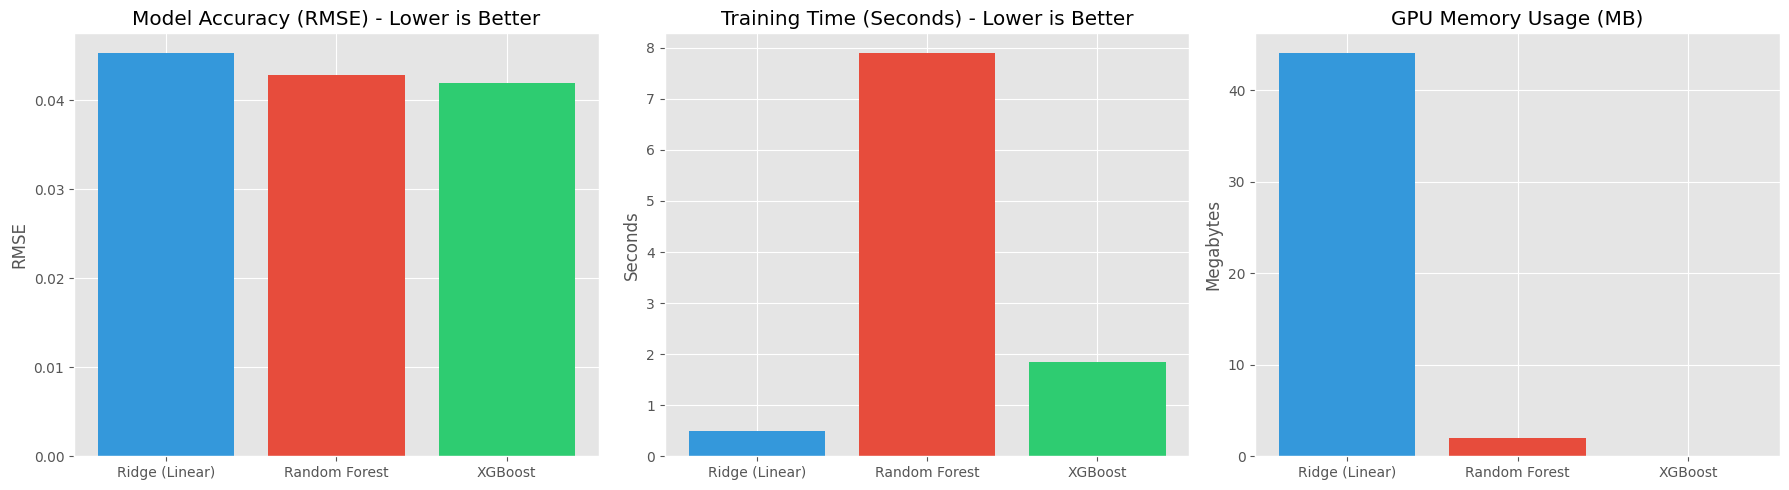

In [11]:
import time
import pynvml
import cudf
import cupy as cp
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from cuml.ensemble import RandomForestRegressor
from cuml.linear_model import Ridge
from cuml.metrics import mean_squared_error

print("--- [1] تهيئة أدوات القياس والبيانات ---")
pynvml.nvmlInit()
handle = pynvml.nvmlDeviceGetHandleByIndex(0)

def get_gpu_metrics():
    mem_info = pynvml.nvmlDeviceGetMemoryInfo(handle)
    utilization = pynvml.nvmlDeviceGetUtilizationRates(handle)
    return mem_info.used / (1024 ** 2), utilization.gpu

# تجهيز البيانات لتتوافق مع cuML
X_train_cuml = cudf.DataFrame(X_train).astype('float32')
y_train_cuml = cudf.Series(y_train).astype('float32')
X_test_cuml = cudf.DataFrame(X_test).astype('float32')
y_test_cuml = cudf.Series(y_test).astype('float32')

# تجهيز بيانات XGBoost (لأنه يتعامل مع Pandas/Dask أو DMatrix بشكل أفضل في بعض النسخ)
X_train_xgb = X_train.to_pandas()
y_train_xgb = y_train.to_pandas()
X_test_xgb = X_test.to_pandas()
y_test_xgb = y_test.to_pandas()

performance_metrics = []

print("--- [2] تدريب النماذج وقياس الأداء ---")

# 1. Ridge Regression
print("جاري تدريب Ridge Regression...")
mem_start, _ = get_gpu_metrics()
t0 = time.time()
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_cuml, y_train_cuml)
train_time_ridge = time.time() - t0
mem_end, util_ridge = get_gpu_metrics()
t1 = time.time()
preds_ridge = ridge_model.predict(X_test_cuml)
inf_time_ridge = time.time() - t1
rmse_ridge = float(cp.sqrt(mean_squared_error(y_test_cuml, preds_ridge)))

performance_metrics.append({
    'Model': 'Ridge (Linear)',
    'RMSE (Lower is Better)': rmse_ridge,
    'Training Time (s)': train_time_ridge,
    'Inference Time (s)': inf_time_ridge,
    'GPU Mem Used (MB)': mem_end - mem_start,
    'GPU Util (%)': util_ridge
})

# 2. Random Forest
print("جاري تدريب Random Forest...")
mem_start, _ = get_gpu_metrics()
t0 = time.time()
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train_cuml, y_train_cuml)
train_time_rf = time.time() - t0
mem_end, util_rf = get_gpu_metrics()
t1 = time.time()
preds_rf = rf_model.predict(X_test_cuml)
inf_time_rf = time.time() - t1
rmse_rf = float(cp.sqrt(mean_squared_error(y_test_cuml, preds_rf)))

performance_metrics.append({
    'Model': 'Random Forest',
    'RMSE (Lower is Better)': rmse_rf,
    'Training Time (s)': train_time_rf,
    'Inference Time (s)': inf_time_rf,
    'GPU Mem Used (MB)': mem_end - mem_start,
    'GPU Util (%)': util_rf
})

# 3. XGBoost
print("جاري تدريب XGBoost...")
mem_start, _ = get_gpu_metrics()
t0 = time.time()
xgb_model = xgb.XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, tree_method='hist', device='cuda', random_state=42)
xgb_model.fit(X_train_xgb, y_train_xgb)
train_time_xgb = time.time() - t0
mem_end, util_xgb = get_gpu_metrics()
t1 = time.time()
preds_xgb = xgb_model.predict(X_test_xgb)
inf_time_xgb = time.time() - t1
from sklearn.metrics import mean_squared_error as mse_sklearn
import numpy as np
rmse_xgb = float(np.sqrt(mse_sklearn(y_test_xgb, preds_xgb)))

performance_metrics.append({
    'Model': 'XGBoost',
    'RMSE (Lower is Better)': rmse_xgb,
    'Training Time (s)': train_time_xgb,
    'Inference Time (s)': inf_time_xgb,
    'GPU Mem Used (MB)': mem_end - mem_start,
    'GPU Util (%)': util_xgb
})

pynvml.nvmlShutdown()

print("\n--- [3] النتائج والمقارنة النهائية ---")
metrics_df = pd.DataFrame(performance_metrics)
display(metrics_df.round(4))

# استخراج الأفضل في كل فئة
best_rmse = metrics_df.loc[metrics_df['RMSE (Lower is Better)'].idxmin()]
fastest_train = metrics_df.loc[metrics_df['Training Time (s)'].idxmin()]

print(f"\n أفضل نموذج من حيث الدقة (أقل خطأ): {best_rmse['Model']} (RMSE: {best_rmse['RMSE (Lower is Better)']:.4f})")
print(f" أسرع نموذج في التدريب: {fastest_train['Model']} ({fastest_train['Training Time (s)']:.4f} ثانية)")

print("\n--- [4] رسم المخططات البيانية للتقرير ---")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.style.use('ggplot')

# رسم دقة النماذج
axes[0].bar(metrics_df['Model'], metrics_df['RMSE (Lower is Better)'], color=['#3498db', '#e74c3c', '#2ecc71'])
axes[0].set_title('Model Accuracy (RMSE) - Lower is Better')
axes[0].set_ylabel('RMSE')

# رسم وقت التدريب
axes[1].bar(metrics_df['Model'], metrics_df['Training Time (s)'], color=['#3498db', '#e74c3c', '#2ecc71'])
axes[1].set_title('Training Time (Seconds) - Lower is Better')
axes[1].set_ylabel('Seconds')

# رسم استهلاك الذاكرة
axes[2].bar(metrics_df['Model'], metrics_df['GPU Mem Used (MB)'], color=['#3498db', '#e74c3c', '#2ecc71'])
axes[2].set_title('GPU Memory Usage (MB)')
axes[2].set_ylabel('Megabytes')

plt.tight_layout()
plt.show()

#### ملخص لنتائج النماذج

In [12]:
print("\n--- [5] النتائج النهائية للنماذج (R2, RMSE, MAE) ---")
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

final_metrics = []

# 1. Ridge
r2_ridge = r2_score(y_test_cuml.to_numpy(), preds_ridge.to_numpy())
mae_ridge = mean_absolute_error(y_test_cuml.to_numpy(), preds_ridge.to_numpy())
final_metrics.append({'Model': 'Ridge', 'RMSE': rmse_ridge, 'R2': r2_ridge, 'MAE': mae_ridge})

# 2. Random Forest
r2_rf = r2_score(y_test_cuml.to_numpy(), preds_rf.to_numpy())
mae_rf = mean_absolute_error(y_test_cuml.to_numpy(), preds_rf.to_numpy())
final_metrics.append({'Model': 'Random Forest', 'RMSE': rmse_rf, 'R2': r2_rf, 'MAE': mae_rf})

# 3. XGBoost
r2_xgb = r2_score(y_test_xgb, preds_xgb)
mae_xgb = mean_absolute_error(y_test_xgb, preds_xgb)
final_metrics.append({'Model': 'XGBoost', 'RMSE': rmse_xgb, 'R2': r2_xgb, 'MAE': mae_xgb})

final_df = pd.DataFrame(final_metrics)
display(final_df.round(4))


--- [5] النتائج النهائية للنماذج (R2, RMSE, MAE) ---


,Model,RMSE,R2,MAE
0,Ridge,0.0452,-0.0056,0.0300
1,Random Forest,0.0428,0.0980,0.0288
2,XGBoost,0.0420,0.1348,0.0285
